In [1]:
# import packages
%load_ext autoreload
%autoreload 2
import os
import sys


sys.path.append(".")
sys.path.append("..")
sys.path.append("../scripts")

import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
# from torchvision.utils import save_image
from dit4science.model.dit_diffusion import create_diffusion
from diffusers.models import AutoencoderKL
from download import find_model  # noqa
from dit4science.model.dit_models import DiT_models
import argparse
import numpy as np

from torchvision import transforms
import matplotlib.pyplot as plt
from dit4science.data.dataset_dit import TurbDataset
from torch.utils.data import DataLoader
from dit4science.utils.bench import get_error, plot_error_curve

/home/chunyang/miniconda3/envs/DiT/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/chunyang/miniconda3/envs/DiT/lib/python3.12/site-packages/diffusers/models/transformers/transformer_2d.py:34: FutureWarning: `Transformer2DModelOutput` is deprecated and will be removed in version 1.0.0. Importing `Transformer2DModelOutput` from `diffusers.models.transformer_2d` is deprecated and this will be removed in a future version. Please use `from diffusers.models.modeling_outputs import Transformer2DModelOutput`, instead.
  deprecate("Transformer2DModelOutput", "1.0.0", deprecation_message)


Number of test loaded: 90
Using fixed maxima [4.65, 2.04, 2.37]
Data stats, input  mean 0.190220, max  0.961052;   targets mean 0.289502 , max 1.000000 
torch.Size([3, 128, 128]) torch.Size([3, 128, 128]) shape info


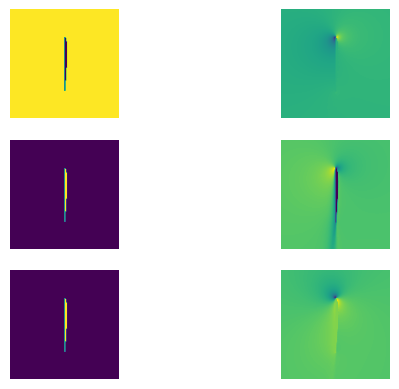

In [20]:
idx = 0
data_path="/home/chunyang/projects/ai4science/DDPM4Science/data/test/"
dataset = TurbDataset(dataDir=data_path, gaussian_norm=False)
sample = dataset[idx]
cond, res = sample

print(cond.shape, res.shape, "shape info")

fig, axs = plt.subplots(3, 2)
for i in range(3):
    for j in range(2):
        axs[i][j].axis("off")

for i in range(3):
    axs[i][0].imshow(cond[i, :, :])
    axs[i][1].imshow(res[i, :, :])
